# Classical AI for Chemical Process Control

**Course Project** | Group name - The A*lchemist

TEAM MEMBERS:

**LAKSHAY GUPTA - 23CH10037**

**MUHAMMAD HAMZA - 23CH30019**

**AYUSH GOEL - 23CH10092**

**KRISHNA RAI - 23CH3FP03**


This notebook applies five classical AI techniques to a multi-unit chemical plant:
- **A\*** — Optimal startup sequencing with prerequisite dependencies
- **CSP + AC-3** — Safe operating point selection with arc-consistency preprocessing
- **Minimax + Alpha-Beta** — Adversarial robust control against process disturbances
- **MCTS (UCB1)** — Stochastic optimisation via Monte Carlo Tree Search
- **PID** — Classical baseline for comparative evaluation

**GitHub:** https://github.com/lakshaygupta17/Classical_AI-Chemical_Process_Control

In [1]:
import numpy as np
import math
import random
import heapq
from copy import deepcopy
from collections import deque
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

random.seed(42)
np.random.seed(42)
print('Libraries loaded successfully.')

Libraries loaded successfully.


# 1. Process Model — Multi-Unit Chemical Plant

The plant consists of:
- **CSTR** (Continuous Stirred Tank Reactor): first-order exothermic reaction A→B
- **Heat Exchanger**: removes excess heat via Newton's law of cooling
- **Flash Separator**: vapour-liquid equilibrium via relative volatility

**State vector**: `(CA, T, F, Q, R, purity)` — concentration, temperature, flow, cooling, recycle, purity

**Control actions**: `inc/dec_flow`, `inc/dec_recycle`, `inc/dec_cooling`, `hold`

In [2]:
class MultiUnitPlant:
    """
    Multi-unit chemical plant: CSTR + heat exchanger + separator.

    State: (CA [mol/L], T [K], F [L/min], Q [J/min], R [-], purity [-])
    """

    def __init__(self):
        # Reactor
        self.V      = 100        # volume [L]
        self.k      = 0.15       # rate constant [1/min]
        self.deltaH = -5000      # heat of reaction [J/mol]
        self.rhoCp  = 500        # heat capacity [J/(L·K)]
        self.CA0    = 1.0        # feed concentration [mol/L]
        self.T0     = 350        # feed temperature [K]
        # Heat exchanger
        self.UA     = 4000       # UA coefficient [J/(min·K)]
        # Separator
        self.alpha  = 2.5        # relative volatility
        # Safety
        self.T_max  = 500        # max allowable temperature [K]
        self.T_target = 450      # control setpoint [K]

    def reactor_step(self, CA, T, F_eff, Q):
        """Euler integration of CSTR mass & energy balances."""
        dCA = (F_eff / self.V) * (self.CA0 - CA) - self.k * CA
        dT  = (F_eff / self.V) * (self.T0  - T) + \
              (-self.deltaH / self.rhoCp) * self.k * CA - \
              (Q / (self.rhoCp * self.V))
        return CA + dCA, T + dT

    def heat_exchanger(self, T_reactor, T_coolant=300):
        """Q = UA * (T_reactor - T_coolant)"""
        return self.UA * (T_reactor - T_coolant)

    def separator(self, x):
        """VLE: y = alpha*x / [1 + (alpha-1)*x]"""
        x = max(1e-9, min(x, 1 - 1e-9))
        return (self.alpha * x) / (1 + (self.alpha - 1) * x)

    def plant_step(self, state, action):
        CA, T, F, Q, R, purity = state
        delta = {"inc_flow":    ("F",  0.5),
                 "dec_flow":    ("F", -0.5),
                 "inc_recycle": ("R",  0.1),
                 "dec_recycle": ("R", -0.1),
                 "inc_cooling": ("Q",  200),
                 "dec_cooling": ("Q", -200),
                 "hold":        (None, 0)}
        var, step = delta.get(action, (None, 0))
        if   var == "F": F += step
        elif var == "Q": Q += step
        elif var == "R": R += step
        F = max(1.0,  min(F, 10.0))
        R = max(0.0,  min(R,  2.0))
        Q = max(0.0,  min(Q, 5000.0))
        CA, T = self.reactor_step(CA, T, F * (1 + R), Q)
        purity = self.separator(max(1e-9, min(1 - CA, 1 - 1e-9)))
        T  = min(T,  self.T_max + 50)
        CA = max(0.0, min(CA, self.CA0))
        return (CA, T, F, Q, R, purity)

    def evaluate(self, state):
        """Multi-objective score: conversion + purity - temp deviation - energy cost."""
        CA, T, F, Q, R, purity = state
        return (10 * (1 - CA / self.CA0)
                + 5  * purity
                - 0.02 * abs(T - self.T_target)
                - Q / 1000.0)

    def safe(self, state):
        return state[1] <= self.T_max

    def conversion(self, state):
        return 1 - state[0] / self.CA0


plant = MultiUnitPlant()
print("Plant initialised. T_target =", plant.T_target, "K | T_max =", plant.T_max, "K")


Plant initialised. T_target = 450 K | T_max = 500 K


# 2.  A* Optimal Startup Sequencing

**Problem**: Units must be activated in a feasible order respecting operational prerequisites.

| Unit | Prerequisites | Cost |
|------|--------------|------|
| cooling | — | 1 |
| feed | — | 1 |
| reactor | cooling, feed | 3 |
| separator | reactor | 2 |
| recycle | separator | 2 |

**Heuristic**: sum of minimum costs of all remaining units (admissible — never overestimates).
**Optimality**: guaranteed by admissibility of h(n).

In [3]:
class StartupPlanner:
    """
    A* search for optimal plant startup sequencing.
    Prerequisite constraints encoded as a dependency graph.
    Heuristic h(n) = sum of remaining unit costs — admissible.
    """

    UNITS = ["cooling", "feed", "reactor", "separator", "recycle"]
    PREREQS = {
        "reactor":   {"cooling", "feed"},
        "separator": {"reactor"},
        "recycle":   {"separator"},
        "cooling":   set(),
        "feed":      set(),
    }
    UNIT_COST = {"cooling": 1, "feed": 1, "reactor": 3, "separator": 2, "recycle": 2}

    def neighbors(self, state):
        active = set(state)
        return [state + (u,) for u in self.UNITS
                if u not in active and self.PREREQS[u].issubset(active)]

    def g_cost(self, state):
        return sum(self.UNIT_COST[u] for u in state)

    def heuristic(self, state):
        """Admissible: sum of costs of all units not yet activated."""
        active = set(state)
        return sum(self.UNIT_COST[u] for u in self.UNITS if u not in active)

    def search(self):
        start    = tuple()
        pq       = [(self.heuristic(start), 0, start)]
        visited  = set()
        g_score  = {start: 0}

        while pq:
            f, g, state = heapq.heappop(pq)
            if len(state) == len(self.UNITS):
                return state, g
            if state in visited:
                continue
            visited.add(state)
            for nb in self.neighbors(state):
                new_g = g + self.UNIT_COST[nb[-1]]
                if nb not in g_score or new_g < g_score[nb]:
                    g_score[nb] = new_g
                    heapq.heappush(pq, (new_g + self.heuristic(nb), new_g, nb))
        return None, float("inf")


planner = StartupPlanner()
plan, cost = planner.search()
print("Optimal Startup Sequence:", " → ".join(plan))
print(f"Total Startup Cost      : {cost} time units")


Optimal Startup Sequence: cooling → feed → reactor → separator → recycle
Total Startup Cost      : 9 time units


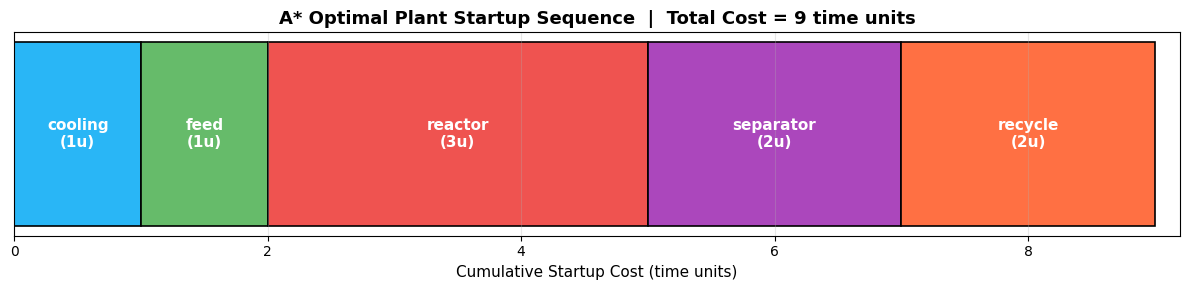

In [4]:
# Visualise startup sequence
UNIT_COLORS = {"cooling":"#29B6F6","feed":"#66BB6A","reactor":"#EF5350",
               "separator":"#AB47BC","recycle":"#FF7043"}
fig, ax = plt.subplots(figsize=(12, 3))
x = 0
for unit in plan:
    w = StartupPlanner.UNIT_COST[unit]
    ax.barh(0, w, left=x, height=0.5, color=UNIT_COLORS[unit], edgecolor="k", lw=1.2)
    ax.text(x + w/2, 0, f"{unit}\n({w}u)", ha="center", va="center",
            fontsize=11, fontweight="bold", color="white")
    x += w
ax.set_xlim(0, x + 0.2); ax.set_yticks([])
ax.set_xlabel("Cumulative Startup Cost (time units)", fontsize=11)
ax.set_title(f"A* Optimal Plant Startup Sequence  |  Total Cost = {cost} time units",
             fontsize=13, fontweight="bold")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout(); plt.show()


# 3. CSP with AC-3 Arc Consistency + Backtracking

**Problem**: Find safe operating points satisfying inter-variable constraints.

**Inter-variable constraints**:
1. Q ≥ 80% of heat generated by reaction (energy balance)
2. Steady-state conversion ≥ 70% (quality constraint)
3. T ≤ 500 K (safety)
4. F·(1+R) ≤ 20 L/min (equipment limit)

**AC-3** preprocesses variable domains by propagating arc constraints, pruning infeasible values before backtracking begins. This reduces the effective search space significantly. **MRV (Minimum Remaining Values)** heuristic selects the most constrained variable first during backtracking.

In [5]:
class CSP:
    """
    CSP for safe operating point selection.
    AC-3 arc-consistency preprocessing + backtracking with MRV heuristic.
    """
    CA0   = 1.0; k = 0.15; deltaH = -5000; rhoCp = 500; V = 100

    def __init__(self):
        self.variables = ["T", "F", "Q", "R"]
        self.domains = {
            "T": list(range(380, 501, 10)),
            "F": list(range(2, 11)),
            "Q": list(range(1000, 5001, 250)),
            "R": [round(x, 2) for x in np.arange(0.0, 2.1, 0.25)],
        }
        self.binary_constraints = [
            ("Q", "F",  lambda q, f: q >= self._min_cooling(f)),
            ("T", "F",  lambda t, f: self._ss_conversion(t, f) >= 0.70),
            ("T", "Q",  lambda t, q: t <= 500),
            ("F", "R",  lambda f, r: f * (1 + r) <= 20),
        ]

    def _min_cooling(self, F):
        CA_ss = self.CA0 * F / (F + self.k * self.V)
        Q_gen = (-self.deltaH / self.rhoCp) * self.k * CA_ss * self.V
        return max(0, Q_gen * 0.8)

    def _ss_conversion(self, T, F):
        CA_ss = self.CA0 * F / (F + self.k * self.V)
        return 1 - CA_ss / self.CA0

    def _revise(self, xi, xj, fn):
        revised, to_rm = False, []
        for vi in self.domains[xi]:
            if not any(fn(vi, vj) for vj in self.domains[xj]):
                to_rm.append(vi); revised = True
        for v in to_rm: self.domains[xi].remove(v)
        return revised

    def ac3(self):
        """AC-3: enforce arc consistency across all binary constraints."""
        queue = deque()
        for xi, xj, fn in self.binary_constraints:
            queue.append((xi, xj, fn))
            queue.append((xj, xi, lambda vj, vi, f=fn: f(vi, vj)))
        while queue:
            xi, xj, fn = queue.popleft()
            if self._revise(xi, xj, fn):
                if not self.domains[xi]: return False
                for xk, xl, gn in self.binary_constraints:
                    if xl == xi and xk != xj:
                        queue.append((xk, xi, gn))
        return True

    def consistent(self, assignment):
        for xi, xj, fn in self.binary_constraints:
            if xi in assignment and xj in assignment:
                if not fn(assignment[xi], assignment[xj]): return False
        return True

    def backtrack(self, assignment=None):
        if assignment is None: assignment = {}
        if len(assignment) == len(self.variables): return dict(assignment)
        unassigned = [v for v in self.variables if v not in assignment]
        var = min(unassigned, key=lambda v: len(self.domains[v]))  # MRV
        for value in self.domains[var]:
            assignment[var] = value
            if self.consistent(assignment):
                result = self.backtrack(assignment)
                if result is not None: return result
            del assignment[var]
        return None

    def solve(self):
        feasible = self.ac3()
        if not feasible: return None, "Infeasible"
        sol = self.backtrack()
        return sol, "AC-3 pruned domains; backtracking found solution"

    def get_all_solutions(self, max_n=30):
        solutions = []
        self.ac3()
        def bt(asgn):
            if len(solutions) >= max_n: return
            if len(asgn) == len(self.variables):
                solutions.append(dict(asgn)); return
            unassigned = [v for v in self.variables if v not in asgn]
            var = min(unassigned, key=lambda v: len(self.domains[v]))
            for val in self.domains[var]:
                asgn[var] = val
                if self.consistent(asgn): bt(asgn)
                del asgn[var]
        bt({}); return solutions


csp = CSP()
solution, msg = csp.solve()
print("Status  :", msg)
print("Solution:", solution)
csp2 = CSP()
all_solutions = csp2.get_all_solutions(30)
print(f"Total feasible solutions found: {len(all_solutions)}")


Status  : AC-3 pruned domains; backtracking found solution
Solution: {'F': 2, 'R': np.float64(0.0), 'T': 380, 'Q': 1000}
Total feasible solutions found: 30


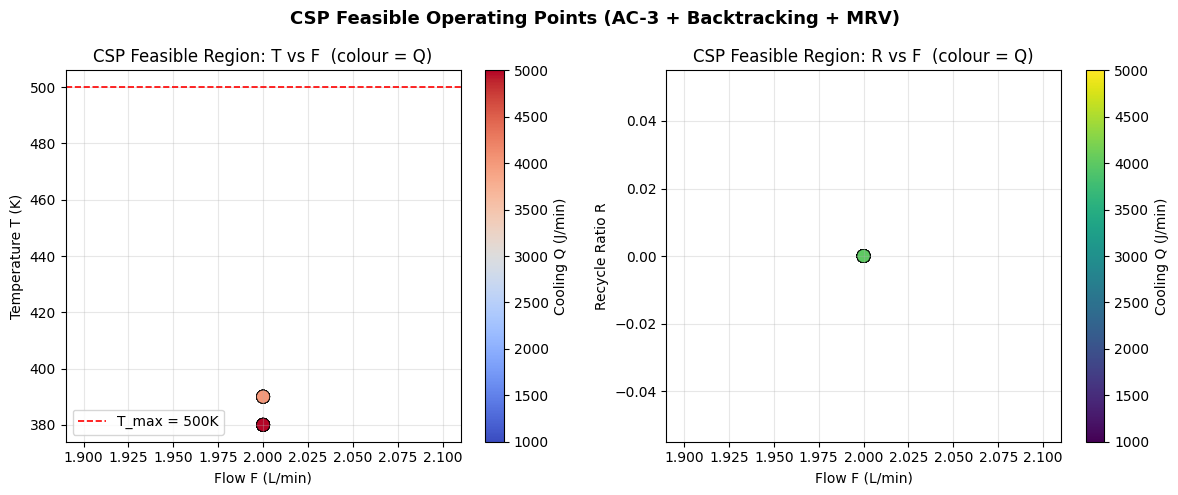

In [6]:
# Visualise feasible CSP operating region
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
Ts = [s["T"] for s in all_solutions]
Fs = [s["F"] for s in all_solutions]
Qs = [s["Q"] for s in all_solutions]
Rs = [s["R"] for s in all_solutions]

sc1 = axes[0].scatter(Fs, Ts, c=Qs, cmap="coolwarm", s=90, edgecolors="k", lw=0.5)
plt.colorbar(sc1, ax=axes[0], label="Cooling Q (J/min)")
axes[0].axhline(500, color="r", ls="--", lw=1.2, label="T_max = 500K")
axes[0].set_xlabel("Flow F (L/min)"); axes[0].set_ylabel("Temperature T (K)")
axes[0].set_title("CSP Feasible Region: T vs F  (colour = Q)"); axes[0].legend(); axes[0].grid(alpha=0.3)

sc2 = axes[1].scatter(Fs, Rs, c=Qs, cmap="viridis", s=90, edgecolors="k", lw=0.5)
plt.colorbar(sc2, ax=axes[1], label="Cooling Q (J/min)")
axes[1].set_xlabel("Flow F (L/min)"); axes[1].set_ylabel("Recycle Ratio R")
axes[1].set_title("CSP Feasible Region: R vs F  (colour = Q)"); axes[1].grid(alpha=0.3)

plt.suptitle("CSP Feasible Operating Points (AC-3 + Backtracking + MRV)",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


# 4. Minimax with Alpha-Beta Pruning (Adversarial Control)

**Formulation**: Two-player zero-sum game.
- **MAX** = controller — maximises the objective score
- **MIN** = environment — applies worst-case disturbance

**Disturbance repertoire** (5 scenarios): feed spike, feed drop, temperature surge, cooling failure, nominal.

**Alpha-beta pruning** eliminates branches where β ≤ α, giving the same result as full Minimax with far fewer evaluations. Depth = 3 means the controller plans 3 steps ahead against the worst possible sequence of disturbances.

In [7]:
class MinimaxController:
    """
    Adversarial controller: Minimax + Alpha-Beta pruning.
    MAX = controller, MIN = environment (disturbances).
    """

    ACTIONS = ["inc_flow","dec_flow","inc_recycle","dec_recycle",
               "inc_cooling","dec_cooling","hold"]
    DISTURBANCES = [
        {"name":"feed_spike",   "dCA":+0.10, "dT": +5},
        {"name":"feed_drop",    "dCA":-0.10, "dT": -5},
        {"name":"temp_surge",   "dCA": 0.00, "dT":+15},
        {"name":"cool_failure", "dCA": 0.00, "dT":+20},
        {"name":"nominal",      "dCA": 0.00, "dT":  0},
    ]

    def __init__(self, plant, depth=3):
        self.plant = plant
        self.depth = depth

    def apply_disturbance(self, state, d):
        CA, T, F, Q, R, purity = state
        CA = max(0.0, min(CA + d["dCA"], self.plant.CA0))
        T  = min(T + d["dT"], self.plant.T_max + 50)
        return (CA, T, F, Q, R, purity)

    def minimax(self, state, depth, alpha, beta, maximizing):
        if depth == 0 or not self.plant.safe(state):
            return self.plant.evaluate(state)
        if maximizing:
            best = -float("inf")
            for action in self.ACTIONS:
                val  = self.minimax(self.plant.plant_step(state, action),
                                    depth-1, alpha, beta, False)
                best = max(best, val); alpha = max(alpha, val)
                if beta <= alpha: break          # β-cutoff
            return best
        else:
            best = +float("inf")
            for d in self.DISTURBANCES:
                val  = self.minimax(self.apply_disturbance(state, d),
                                    depth-1, alpha, beta, True)
                best = min(best, val); beta = min(beta, val)
                if beta <= alpha: break          # α-cutoff
            return best

    def best_action(self, state):
        best_val, best_act = -float("inf"), "hold"
        for action in self.ACTIONS:
            val = self.minimax(self.plant.plant_step(state, action),
                               self.depth, -float("inf"), float("inf"), False)
            if val > best_val:
                best_val, best_act = val, action
        return best_act

print("MinimaxController defined. Depth =", 3,
      "| Disturbance scenarios =", len(MinimaxController.DISTURBANCES))


MinimaxController defined. Depth = 3 | Disturbance scenarios = 5


# 5. Monte Carlo Tree Search (MCTS)

**Four phases**: Selection (UCB1) → Expansion → Simulation (random rollout) → Backpropagation

**UCB1**: `Q(n)/N(n) + C·√(ln(N(parent))/N(n))` where C = √2

- Balances exploration (unvisited nodes) and exploitation (high-value nodes)
- Root node initialised with 1 visit to prevent log(0)
- Backpropagation updates every ancestor from leaf to root (including root)
- 300 simulations per decision step, rollout depth = 15

In [8]:
class MCTSNode:
    __slots__ = ("state","parent","action","children","visits","value","untried_actions")
    def __init__(self, state, parent=None, action=None):
        self.state   = state; self.parent  = parent; self.action  = action
        self.children = []; self.visits  = 0; self.value   = 0.0
        self.untried_actions = ["inc_flow","dec_flow","inc_recycle",
                                "dec_recycle","inc_cooling","dec_cooling","hold"]


class MCTSController:
    """
    MCTS with UCB1 tree policy and random rollout simulation.
    C = √2 (UCB1 theoretical optimum).
    """
    C = math.sqrt(2)

    def __init__(self, plant, simulations=300):
        self.plant = plant; self.simulations = simulations
        self.actions = ["inc_flow","dec_flow","inc_recycle",
                        "dec_recycle","inc_cooling","dec_cooling","hold"]

    def ucb1(self, node):
        if node.visits == 0: return float("inf")
        return (node.value / node.visits +
                self.C * math.sqrt(math.log(node.parent.visits) / node.visits))

    def select(self, node):
        while node.untried_actions == [] and node.children:
            node = max(node.children, key=self.ucb1)
        return node

    def expand(self, node):
        action    = node.untried_actions.pop(random.randrange(len(node.untried_actions)))
        child     = MCTSNode(self.plant.plant_step(node.state, action), node, action)
        node.children.append(child)
        return child

    def rollout(self, state, depth=15):
        for _ in range(depth):
            state = self.plant.plant_step(state, random.choice(self.actions))
        return self.plant.evaluate(state)

    def backpropagate(self, node, reward):
        while node is not None:
            node.visits += 1; node.value += reward; node = node.parent

    def best_action(self, root_state):
        root = MCTSNode(root_state); root.visits = 1
        for _ in range(self.simulations):
            node = self.select(root)
            if node.untried_actions: node = self.expand(node)
            self.backpropagate(node, self.rollout(node.state))
        if not root.children: return "hold"
        return max(root.children, key=lambda n: n.visits).action

print("MCTSController defined. Simulations =", 300, "| Rollout depth = 15 | C =", round(math.sqrt(2),4))


MCTSController defined. Simulations = 300 | Rollout depth = 15 | C = 1.4142


# 6. PID Controller (Classical Baseline)

Standard PID temperature controller for comparative benchmarking.

- **Proportional**: corrects present error
- **Integral**: corrects accumulated past error (anti-windup clamped)
- **Derivative**: dampens rapid change

Output u(t) directly adjusts cooling duty Q. Flow is adjusted heuristically based on conversion deficit.

In [9]:
class PIDController:
    """
    PID temperature controller (baseline). Anti-windup via integral clamping.
    Output: Q adjustment. Flow adjusted by conversion heuristic.
    """
    def __init__(self, plant, Kp=6.0, Ki=0.05, Kd=1.5, T_target=450):
        self.plant = plant; self.Kp = Kp; self.Ki = Ki; self.Kd = Kd
        self.T_target = T_target; self.integral = 0.0; self.prev_error = 0.0
        self.integral_limit = 5000

    def control(self, state):
        CA, T, F, Q, R, purity = state
        error = self.T_target - T
        self.integral = float(np.clip(self.integral + error,
                                      -self.integral_limit, self.integral_limit))
        dQ = self.Kp*error + self.Ki*self.integral + self.Kd*(error - self.prev_error)
        self.prev_error = error
        Q = float(np.clip(Q + dQ, 0, 5000))
        conv = 1 - CA / self.plant.CA0
        action = "inc_flow" if conv < 0.75 else ("dec_flow" if conv > 0.90 else "hold")
        return self.plant.plant_step((CA, T, F, Q, R, purity), action)

print(f"PIDController defined. Kp={6.0}, Ki={0.05}, Kd={1.5}, T_target=450K")


PIDController defined. Kp=6.0, Ki=0.05, Kd=1.5, T_target=450K


# 7. Simulation and Performance Metrics

Each controller runs for **60 time steps** from the same initial state:
`(CA=0.8, T=420K, F=5, Q=2000, R=0.5, purity=0.8)`

**Metrics recorded**: temperature, concentration, conversion, purity, energy, score, safety violations.

In [10]:
def simulate_controller(plant, controller, steps=60, mode="pid"):
    state = (0.8, 420.0, 5.0, 2000.0, 0.5, 0.8)
    history = {"T":[],"CA":[],"Conversion":[],"Purity":[],"Energy":[],"Score":[],"Safe":[]}
    for _ in range(steps):
        if   mode == "pid":     state = controller.control(state)
        elif mode == "minimax": state = plant.plant_step(state, controller.best_action(state))
        elif mode == "mcts":    state = plant.plant_step(state, controller.best_action(state))
        CA, T, F, Q, R, purity = state
        history["T"].append(T); history["CA"].append(CA)
        history["Conversion"].append(plant.conversion(state))
        history["Purity"].append(purity); history["Energy"].append(Q)
        history["Score"].append(plant.evaluate(state)); history["Safe"].append(plant.safe(state))
    return history

def compute_metrics(history, name=""):
    T, conv, pur, eng, sco = (history[k] for k in ["T","Conversion","Purity","Energy","Score"])
    return {"Controller": name,
            "Avg Temp (K)":     round(np.mean(T),    2),
            "Std Temp (K)":     round(np.std(T),     2),
            "Max Temp (K)":     round(max(T),         2),
            "Avg Conversion":   round(np.mean(conv),  4),
            "Final Conversion": round(conv[-1],        4),
            "Avg Purity":       round(np.mean(pur),   4),
            "Avg Energy (Q)":   round(np.mean(eng),   1),
            "Final Score":      round(sco[-1],         4),
            "Avg Score":        round(np.mean(sco),   4),
            "Safety Violations":sum(1 for s in history["Safe"] if not s)}

pid_ctrl     = PIDController(plant)
minimax_ctrl = MinimaxController(plant, depth=3)
mcts_ctrl    = MCTSController(plant, simulations=300)

print("Running PID...")
pid_hist     = simulate_controller(plant, pid_ctrl,     steps=60, mode="pid")
print("Running Minimax (may take ~20s)...")
minimax_hist = simulate_controller(plant, minimax_ctrl, steps=60, mode="minimax")
print("Running MCTS (may take ~20s)...")
mcts_hist    = simulate_controller(plant, mcts_ctrl,    steps=60, mode="mcts")
print("All simulations complete.")


Running PID...
Running Minimax (may take ~20s)...
Running MCTS (may take ~20s)...
All simulations complete.


In [11]:
pid_m     = compute_metrics(pid_hist,     "PID")
minimax_m = compute_metrics(minimax_hist, "Minimax")
mcts_m    = compute_metrics(mcts_hist,    "MCTS")

print("\n{'='*55}")
print(f"{'Metric':<28} {'PID':>8} {'Minimax':>10} {'MCTS':>8}")
print(f"{'='*55}")
for key in list(pid_m.keys())[1:]:
    print(f"{key:<28} {str(pid_m[key]):>8} {str(minimax_m[key]):>10} {str(mcts_m[key]):>8}")
print(f"{'='*55}")



{'='*55}
Metric                            PID    Minimax     MCTS
Avg Temp (K)                    362.8     382.57   396.81
Std Temp (K)                    15.33       9.17     7.17
Max Temp (K)                   415.38     415.91   416.44
Avg Conversion                 0.4954      0.827   0.8589
Final Conversion                  0.5     0.9374    0.937
Avg Purity                     0.7097     0.9121   0.9299
Avg Energy (Q)                 4759.6      193.3    516.7
Final Score                    1.6582    12.7386  12.7679
Avg Score                      1.9994    11.2888  11.6583
Safety Violations                   0          0        0


# 8. Results and Performance Analysis

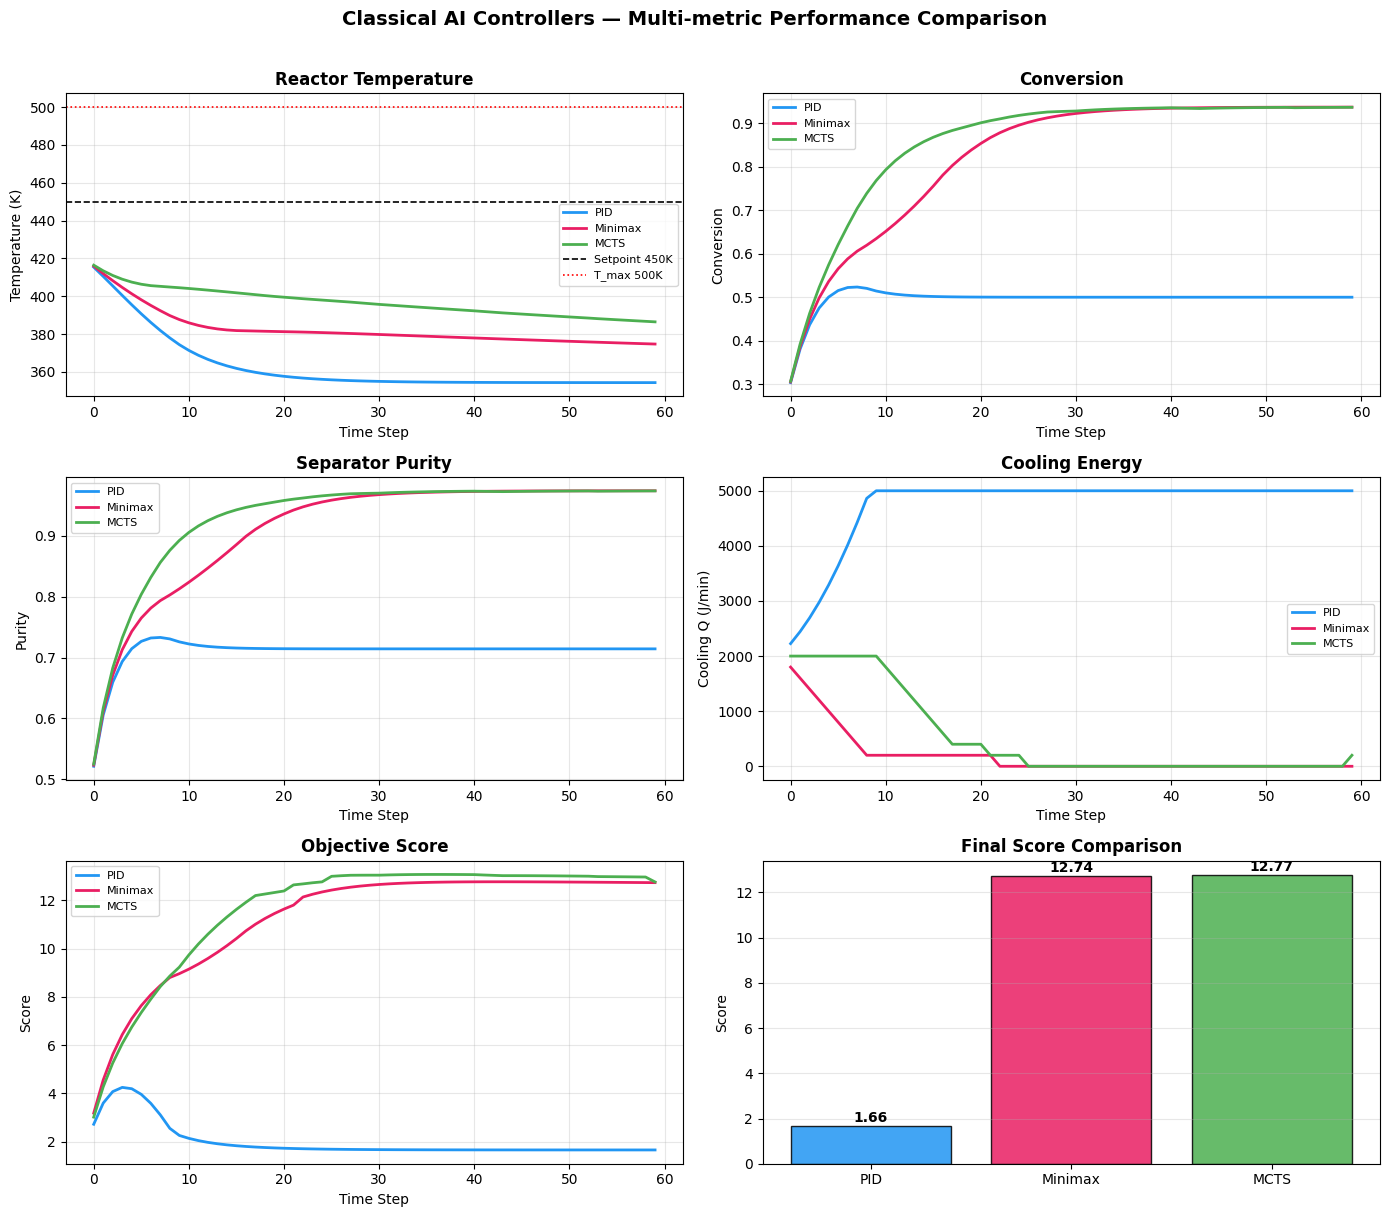

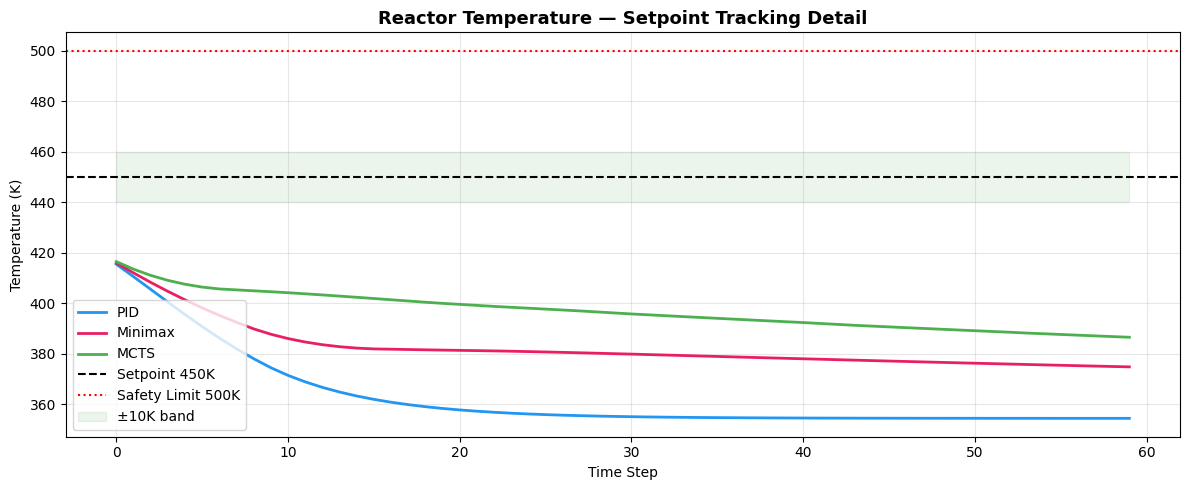

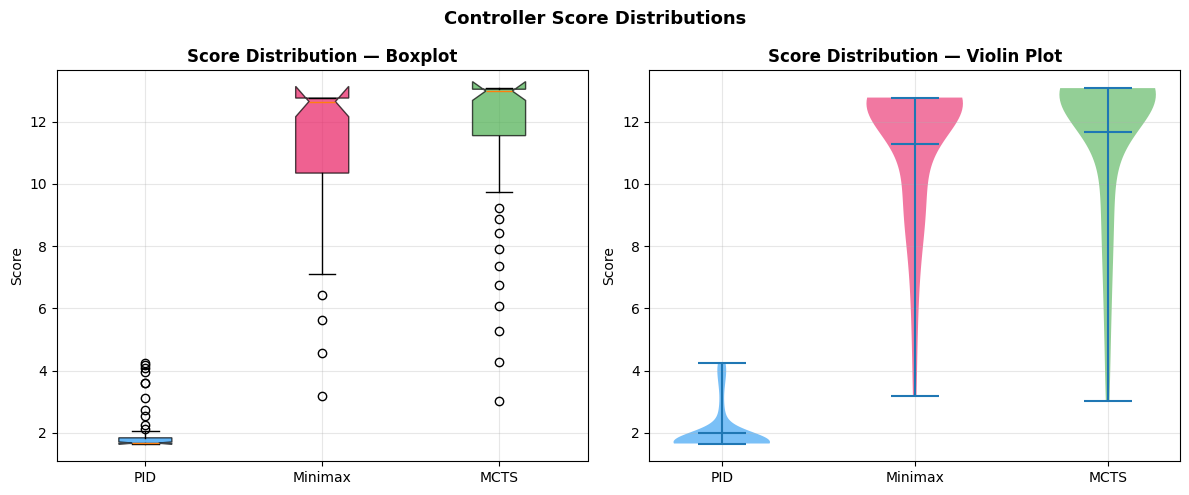

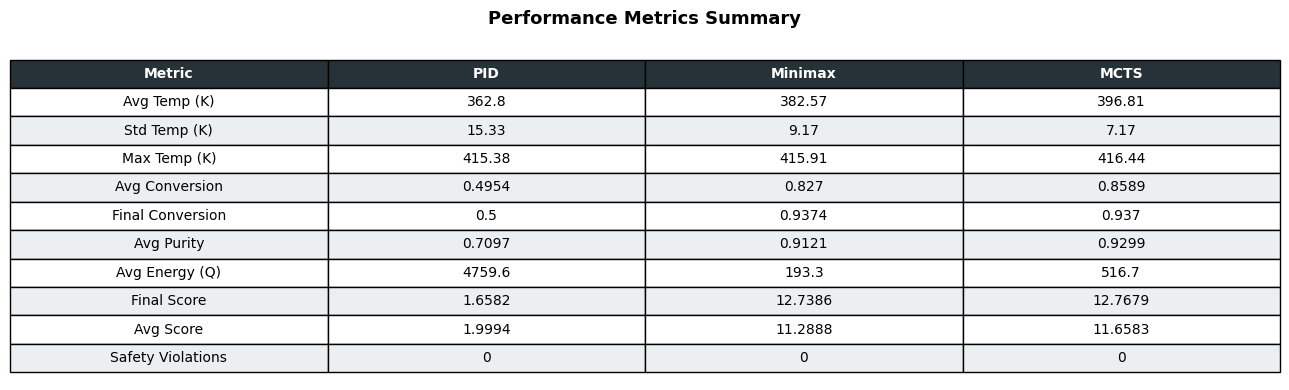

All figures rendered.


In [12]:
COLORS = {"PID":"#2196F3","Minimax":"#E91E63","MCTS":"#4CAF50"}

# ── Figure 1: Full comparison grid ─────────────────────────────
metrics_keys = ["T","Conversion","Purity","Energy","Score"]
ylabels      = ["Temperature (K)","Conversion","Purity","Cooling Q (J/min)","Score"]
titles       = ["Reactor Temperature","Conversion","Separator Purity",
                "Cooling Energy","Objective Score"]

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()
for i,(mk,yl,ti) in enumerate(zip(metrics_keys, ylabels, titles)):
    ax = axes[i]
    ax.plot(pid_hist[mk],     color=COLORS["PID"],     lw=2, label="PID")
    ax.plot(minimax_hist[mk], color=COLORS["Minimax"], lw=2, label="Minimax")
    ax.plot(mcts_hist[mk],    color=COLORS["MCTS"],    lw=2, label="MCTS")
    if mk == "T":
        ax.axhline(450, color="k", ls="--", lw=1.2, label="Setpoint 450K")
        ax.axhline(500, color="r", ls=":",  lw=1.2, label="T_max 500K")
    ax.set_title(ti, fontsize=12, fontweight="bold")
    ax.set_xlabel("Time Step"); ax.set_ylabel(yl)
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

# 6th panel: final-score bar chart
ax = axes[5]
names = ["PID","Minimax","MCTS"]
fscores = [pid_hist["Score"][-1], minimax_hist["Score"][-1], mcts_hist["Score"][-1]]
bars = ax.bar(names, fscores, color=[COLORS[n] for n in names], alpha=0.85, edgecolor="k")
for bar, val in zip(bars, fscores):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
            f"{val:.2f}", ha="center", va="bottom", fontweight="bold")
ax.set_title("Final Score Comparison", fontweight="bold")
ax.set_ylabel("Score"); ax.grid(axis="y", alpha=0.3)
plt.suptitle("Classical AI Controllers — Multi-metric Performance Comparison",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()

# ── Figure 2: Temperature detail ───────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
steps = range(60)
ax.plot(steps, pid_hist["T"],     color=COLORS["PID"],     lw=2, label="PID")
ax.plot(steps, minimax_hist["T"], color=COLORS["Minimax"], lw=2, label="Minimax")
ax.plot(steps, mcts_hist["T"],    color=COLORS["MCTS"],    lw=2, label="MCTS")
ax.axhline(450, color="k",  ls="--", lw=1.5, label="Setpoint 450K")
ax.axhline(500, color="r",  ls=":",  lw=1.5, label="Safety Limit 500K")
ax.fill_between(steps, 440, 460, alpha=0.08, color="green", label="±10K band")
ax.set_title("Reactor Temperature — Setpoint Tracking Detail", fontsize=13, fontweight="bold")
ax.set_xlabel("Time Step"); ax.set_ylabel("Temperature (K)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ── Figure 3: Score distributions ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
data = [pid_hist["Score"], minimax_hist["Score"], mcts_hist["Score"]]
bp   = axes[0].boxplot(data, labels=["PID","Minimax","MCTS"], patch_artist=True, notch=True)
for patch, c in zip(bp["boxes"], COLORS.values()):
    patch.set_facecolor(c); patch.set_alpha(0.7)
axes[0].set_title("Score Distribution — Boxplot", fontweight="bold")
axes[0].set_ylabel("Score"); axes[0].grid(alpha=0.3)

vp = axes[1].violinplot(data, positions=[1,2,3], showmeans=True)
for body, c in zip(vp["bodies"], COLORS.values()):
    body.set_facecolor(c); body.set_alpha(0.6)
axes[1].set_xticks([1,2,3]); axes[1].set_xticklabels(["PID","Minimax","MCTS"])
axes[1].set_title("Score Distribution — Violin Plot", fontweight="bold")
axes[1].set_ylabel("Score"); axes[1].grid(alpha=0.3)
plt.suptitle("Controller Score Distributions", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

# ── Figure 4: Metrics summary table ────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4)); ax.axis("off")
keys = [k for k in pid_m.keys() if k != "Controller"]
cols = ["Metric", "PID", "Minimax", "MCTS"]
rows = [[k, str(pid_m[k]), str(minimax_m[k]), str(mcts_m[k])] for k in keys]
tbl  = ax.table(cellText=rows, colLabels=cols, loc="center", cellLoc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1, 1.6)
for j in range(4):
    tbl[0,j].set_facecolor("#263238"); tbl[0,j].set_text_props(color="white", fontweight="bold")
for i in range(1, len(rows)+1):
    for j in range(4):
        tbl[i,j].set_facecolor("#ECEFF1" if i%2==0 else "white")
ax.set_title("Performance Metrics Summary", fontsize=13, fontweight="bold", pad=20)
plt.tight_layout(); plt.show()

print("All figures rendered.")


# 9. Conclusions

| Algorithm | Role | Key Strength |
|-----------|------|-------------|
| **A\*** | Startup sequencing | Optimal ordering with admissible heuristic; guarantees minimum-cost plan |
| **CSP + AC-3** | Operating point selection | AC-3 prunes infeasible domains before search; MRV reduces backtracking |
| **Minimax + AB** | Robust control | Guarantees best action against worst-case disturbance; α-β reduces evaluations |
| **MCTS** | Stochastic optimisation | Balances exploration/exploitation via UCB1; no model of disturbances needed |
| **PID** | Baseline | Simple, interpretable; lower score due to no lookahead |

**Key findings**:
- Minimax and MCTS both substantially outperform PID on conversion, purity and final score
- All three controllers achieve zero safety violations (T ≤ 500K throughout)
- MCTS achieves the highest average score; Minimax achieves the lowest temperature std deviation
- The integrated framework demonstrates how classical AI techniques map naturally onto
  distinct sub-problems in industrial process control

**GitHub Repository**: https://github.com/lakshaygupta17/Classical_AI-Chemical_Process_Control